# Gas Classification Model Drift Analysis using Random Forest

This notebook evaluates the performance of a gas classification model over time by:
1. Loading a gas sensor dataset with multiple batches of measurements
2. Extracting features and target labels from the first batch
3. Training a Random Forest Classifier on a subset of batch 1
4. Evaluating model performance on subsequent batches (2–9)
5. Visualising accuracy drift over time with a line plot

The notebook demonstrates how model performance can change across data batches
collected over time, potentially indicating concept drift or sensor degradation.

**Data source:** Vergara et al. (2012). *Chemical gas sensor drift compensation
using classifier ensembles.* Sensors and Actuators B Chemical, 166–167, 320–329.
https://doi.org/10.1016/j.snb.2012.01.074

## Load the Dataset

The dataset is stored as a pickle file containing a pandas DataFrame with
sensor measurements across multiple batches and a `batch_id` column.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load the dataset from pickle file
with open("dataset/dataset.pkl", "rb") as f:
   data = pickle.load(f)

## Prepare Training Data from Batch 1

Only batch 1 is used for training. The last 5 columns are metadata
(including `batch_id` and `gas_class`) and are excluded from the feature matrix.

In [2]:
# Extract data from the first batch
batch1 = data.where(data["batch_id"] == 1).dropna()
batch1_y = batch1["gas_class"].to_numpy()
batch1_X = batch1[batch1.columns[:-5]].to_numpy()  # Exclude metadata columns

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(batch1_X, batch1_y, random_state=0, test_size=0.1)

## Train Random Forest Classifier

A Random Forest with 1,000 trees is trained on batch 1. The accuracy on the
held-out batch 1 test set serves as the baseline (batch index 1 in the plot).

In [3]:
# Train a random forest classifier
model = RandomForestClassifier(n_estimators=1000, random_state=0)
model.fit(X_train, y_train)

# Evaluate the model on batch 1 test set using accuracy = correct / total
y_pred = model.predict(X_test)
accuracy = [accuracy_score(y_test, y_pred)]

## Evaluate Model Drift Across Batches

The same model (trained only on batch 1) is applied to each subsequent batch
without retraining. A drop in accuracy across batches indicates concept drift
or degradation in sensor calibration over time.

In [4]:
# Evaluate model performance on subsequent batches (2-9)
for i in range(2, 10):
   # Extract data from the batch
   batch = data.where(data["batch_id"] == i).dropna()
   batch_y = batch["gas_class"].to_numpy()
   batch_X = batch[batch.columns[:-5]].to_numpy()

   # Predict the gas class
   y_pred = model.predict(batch_X)

   # Evaluate the model and store accuracy
   accuracy = np.append(accuracy, accuracy_score(batch_y, y_pred))

## Plot Accuracy Over Time

The accuracy curve shows how the model generalises from batch 1 to later
batches. A declining trend is a signature of model drift.

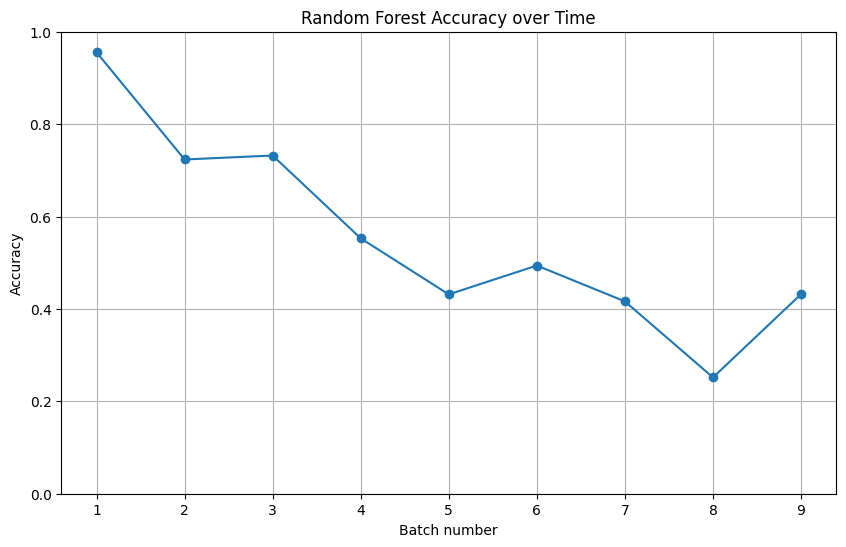

In [5]:
# Plot the accuracy of the model over time
plt.figure(figsize=(10, 6))
plt.plot(range(1, 10), accuracy, marker='o')
plt.xlabel('Batch number')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.title('Random Forest Accuracy over Time')
plt.grid(True)
plt.show()